Handling Imbalanced Dataset

1. UP sampling 
2. Down sampling

In [3]:
import numpy as np 
import pandas as pd

np.random.seed(123)

n_sample = 1000
class_0_ratio = 0.9 
n_class_0 = int(n_sample*class_0_ratio)
n_class_1 = n_sample- n_class_0

n_class_0, n_class_1


(900, 100)

In [8]:
## create my dataframe with imbalanced datasets

class_0 = pd.DataFrame({
    'Feature_1 ': np.random.normal(loc= 0, scale =1, size= n_class_0), 
    'feature_2': np.random.normal(loc = 0, scale= 1, size= n_class_0),
    'target': [0]*n_class_0
})


class_1 = pd.DataFrame({
    'Feature_1 ': np.random.normal(loc= 2, scale =1, size= n_class_1), 
    'feature_2': np.random.normal(loc = 2, scale= 1, size= n_class_1),
    'target': [1]*n_class_1
})

In [10]:
df = pd.concat([class_0, class_1]).reset_index(drop=True)
df

,Feature_1,feature_2,target
0,-1.774224,0.285744,0
1,-1.201377,0.333279,0
2,1.096257,0.531807,0
3,0.861037,-0.354766,0
4,-1.520367,-1.120815,0
...,...,...,...
995,2.677156,1.092048,1
996,2.963404,0.181955,1
997,1.621476,1.877267,1
998,3.429559,3.794486,1


In [11]:
### upsampling 
df_majority = df[df['target']==0]
df_minority = df[df['target']==1]

In [14]:
from sklearn.utils import resample

df_minority_upsampled = resample(df_minority, replace=True, n_samples=len(df_majority), random_state=42)

In [16]:
df_minority_upsampled.shape

(900, 3)

In [18]:
df_minority_upsampled.head()

,Feature_1,feature_2,target
951,2.905343,1.495151,1
992,2.000977,1.814833,1
914,1.927957,2.280911,1
971,2.819483,2.964646,1
960,2.456515,1.833528,1


In [25]:
df_upsampled = pd.concat([df_majority ,df_minority_upsampled])

In [26]:
df_upsampled['target'].value_counts()

target
0    900
1    900
Name: count, dtype: int64

### Up Sampled

In [28]:
import numpy as np 
import pandas as pd

np.random.seed(123)

n_sample = 1000
class_0_ratio = 0.9 
n_class_0 = int(n_sample*class_0_ratio)
n_class_1 = n_sample- n_class_0

n_class_0, n_class_1



## create my dataframe with imbalanced datasets

class_0 = pd.DataFrame({
    'Feature_1 ': np.random.normal(loc= 0, scale =1, size= n_class_0), 
    'feature_2': np.random.normal(loc = 0, scale= 1, size= n_class_0),
    'target': [0]*n_class_0
})


class_1 = pd.DataFrame({
    'Feature_1 ': np.random.normal(loc= 2, scale =1, size= n_class_1), 
    'feature_2': np.random.normal(loc = 2, scale= 1, size= n_class_1),
    'target': [1]*n_class_1
})

df = pd.concat([class_0, class_1]).reset_index(drop=True)
df

print(df['target'].value_counts())

target
0    900
1    100
Name: count, dtype: int64


In [ ]:
### Dowmnsampling 
df_majority = df[df['target']==0]
df_minority = df[df['target']==1]

In [40]:
from sklearn.utils import resample

df_majority_downsampled = resample(df_minority,replace=False, n_samples=len(df_minority), random_state=42)

In [32]:
df_majority_downsampled.shape

(100, 3)

In [37]:
df_downsampled = pd.concat([df_minority, df_majority_downsampled])

In [38]:
df_downsampled['target'].value_counts()

target
1    200
Name: count, dtype: int64

## using SMOTE

In [41]:
from sklearn.datasets import make_classification

In [44]:
x, y = make_classification(
    n_samples= 1000, n_redundant=0, n_features= 2, n_clusters_per_class= 1,
    weights= [0.90],random_state= 12
)


In [50]:
import pandas as pd 

df1 = pd.DataFrame(x, columns= ['f1','f2'])
df2 = pd.DataFrame(y, columns = ['target'])
final_df = pd.concat([df1, df2], axis= True)
final_df.head()

,f1,f2,target
0,-0.762898,-0.706808,0
1,-1.075436,-1.051162,0
2,-0.610115,-0.909802,0
3,-2.023284,-0.428945,1
4,-0.812921,-1.316206,0


In [51]:
final_df['target'].value_counts()

target
0    900
1    100
Name: count, dtype: int64

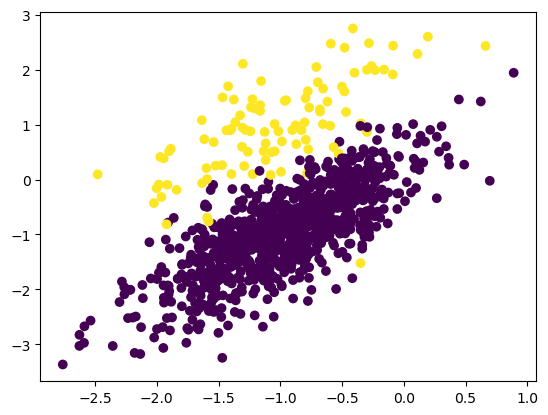

In [52]:
import matplotlib.pyplot as plt 

plt.scatter(final_df['f1'], final_df['f2'], c= final_df['target'])

In [53]:
from imblearn.over_sampling import SMOTE

In [54]:
## transform the datasets 

oversample = SMOTE()
x,y = oversample.fit_resample(final_df[['f1','f2']], final_df['target']) 

In [57]:
x.shape 
y.shape

(1800,)

In [60]:
len(y[y==0])


900

In [62]:
len(y[y==1])


900

In [61]:
len(x[x==0])


1800

In [63]:
len(x[x==1])


1800

In [68]:
df1 = pd.DataFrame(x, columns= ['f1','f2'])
df2 = pd.DataFrame(y, columns = ['target'])


oversample_df = pd.concat([df1, df2], axis=1)

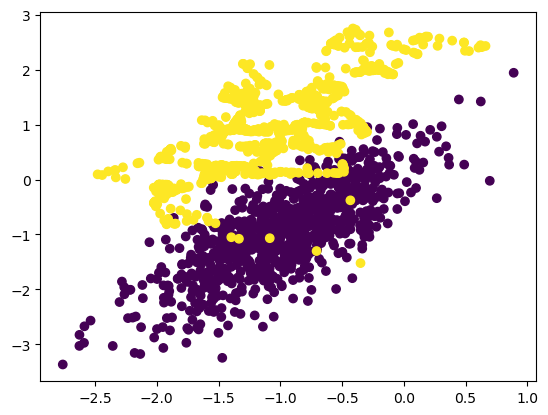

In [69]:
import matplotlib.pyplot as plt 

plt.scatter(oversample_df['f1'], oversample_df['f2'], c= oversample_df['target'])